# Employee Attrition and Workforce Analytics
## IDRA Capstone Project 7

End-to-end machine learning workflow: data understanding, cleaning, EDA, preprocessing, modelling, and evaluation. Raw and cleaned data are stored in `data/`; figures for the report are saved in `figures/`. Positive class: **Attrition = Yes**.

## 0. Environment setup

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
RAW_NAME = "P_7_WA_Fn-UseC_-HR-Employee-Attrition.csv"
candidate_roots = [Path.cwd(), Path.cwd() / "Project", Path.cwd().parent]
ROOT = next(
    (
        root for root in candidate_roots
        if (root / "data" / RAW_NAME).exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        f"Could not find {RAW_NAME!r} in the expected project locations."
    )
DATA = ROOT / "data"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
RAW_PATH = DATA / RAW_NAME
CLEAN_PATH = DATA / "employee_attrition_cleaned.csv"
PALETTE = {"No": "#4C78A8", "Yes": "#E45756"}
sns.set_theme(style="whitegrid", context="notebook")

def save_figure(filename):
    plt.tight_layout()
    plt.savefig(FIGURES / filename, dpi=220, bbox_inches="tight")
    plt.close()

def rate_table(frame, column):
    result = frame.groupby(column, observed=False)["AttritionBinary"].agg(Employees="count", AttritionRate="mean").reset_index()
    result["AttritionRate"] *= 100
    return result.sort_values("AttritionRate", ascending=False)

## 1. Load data and initial understanding

Load the LMS-supplied CSV from `data/` without modifying the raw file on disk.

In [20]:
raw = pd.read_csv(RAW_PATH)
print('File:', RAW_PATH.name)
print('Shape:', raw.shape)
print('\nColumn dtypes:\n', raw.dtypes)
display(raw.head())
display(raw.describe(include='all').transpose().head(15))
target_counts = raw['Attrition'].value_counts()
baseline_rate = (raw['Attrition'] == 'Yes').mean() * 100
print('\nAttrition counts:\n', target_counts)
print(f'Baseline attrition rate: {baseline_rate:.2f}%')

File: P_7_WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)

Column dtypes:
 Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0



Attrition counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64
Baseline attrition rate: 16.12%


## 2. Data cleaning and quality checks

Document missing values, duplicates, category consistency, valid ranges, and IQR-based outlier review.

In [21]:
missing = raw.isna().sum()
duplicates = raw.duplicated().sum()
print('Total missing values:', missing.sum())
print('Duplicate rows:', duplicates)

clean = raw.copy()
text_columns = clean.select_dtypes(include=['object', 'string']).columns
for column in text_columns:
    clean[column] = clean[column].astype(str).str.strip()
clean['AttritionBinary'] = (clean['Attrition'] == 'Yes').astype(int)

for column in ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany']:
    print(column, 'min/max:', clean[column].min(), clean[column].max())

outlier_rows = []
for column in ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany']:
    q1, q3 = clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    flagged = ((clean[column] < q1 - 1.5 * iqr) | (clean[column] > q3 + 1.5 * iqr)).sum()
    outlier_rows.append({'Variable': column, 'IQR_flagged': int(flagged)})
display(pd.DataFrame(outlier_rows))

clean.to_csv(CLEAN_PATH, index=False)
print('Saved cleaned data to', CLEAN_PATH)

Total missing values: 0
Duplicate rows: 0
Age min/max: 18 60
MonthlyIncome min/max: 1009 19999
TotalWorkingYears min/max: 0 40
YearsAtCompany min/max: 0 40


,Variable,IQR_flagged
0,Age,0
1,MonthlyIncome,114
2,DistanceFromHome,0
3,TotalWorkingYears,63
4,YearsAtCompany,104


Saved cleaned data to d:\IDRA\IDRA\Project\capstone_project_7\data\employee_attrition_cleaned.csv


## 3. Exploratory data analysis (EDA)

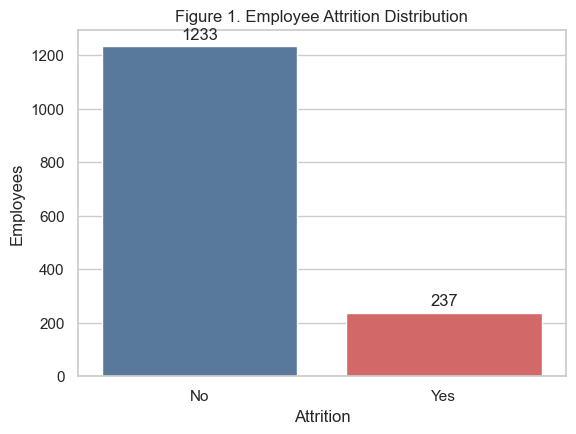

,OverTime,Employees,AttritionRate
1,Yes,416,30.528846
0,No,1054,10.436433


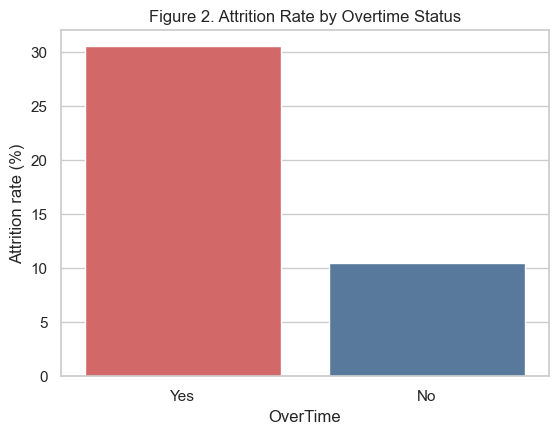

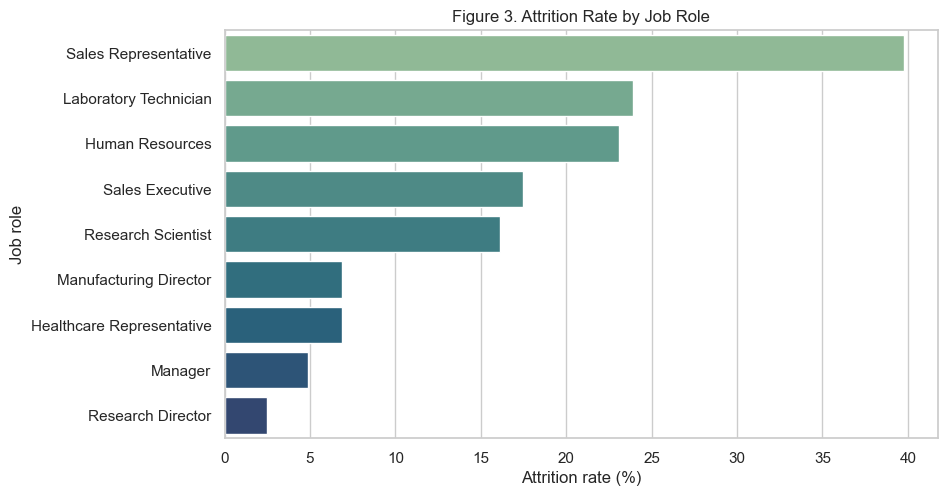

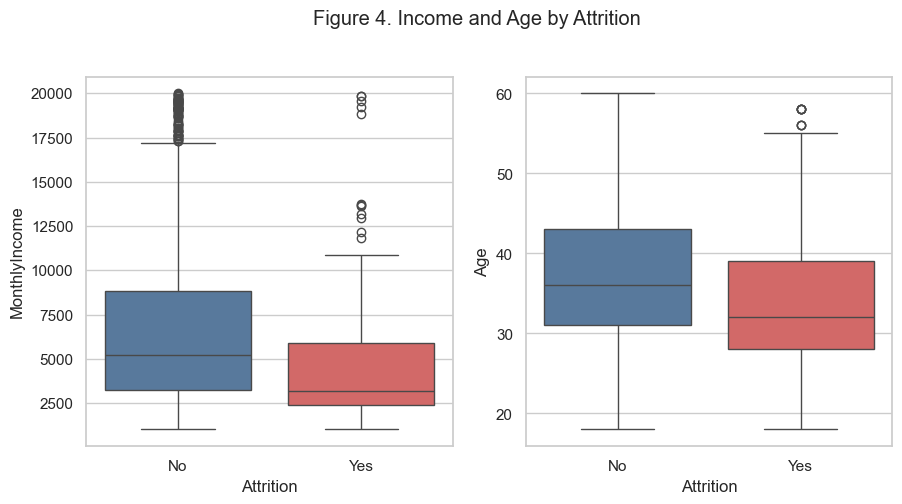

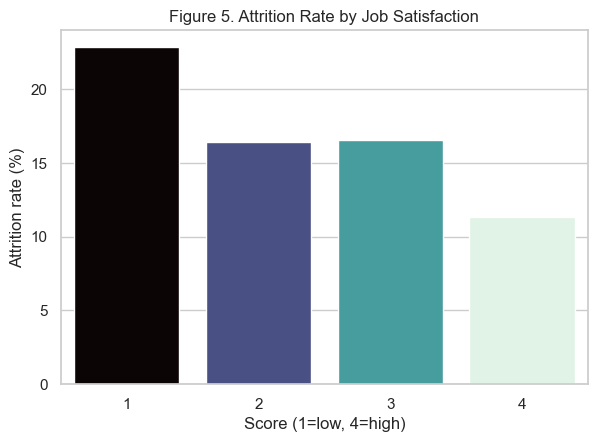

In [29]:
plt.figure(figsize=(6.3, 4.5))
ax = sns.countplot(data=clean, x='Attrition', hue='Attrition', order=['No', 'Yes'], palette=PALETTE, legend=False)
ax.set(title='Figure 1. Employee Attrition Distribution', xlabel='Attrition', ylabel='Employees')
for container in ax.containers: ax.bar_label(container, padding=3)
plt.show()
save_figure('figure_1_attrition_distribution.png')


overtime_table = rate_table(clean, 'OverTime')
display(overtime_table)
plt.figure(figsize=(6.3, 4.5))
ax = sns.barplot(data=overtime_table, x='OverTime', y='AttritionRate', hue='OverTime', palette=PALETTE, legend=False)
ax.set(title='Figure 2. Attrition Rate by Overtime Status', xlabel='OverTime', ylabel='Attrition rate (%)')
plt.show()
save_figure('figure_2_overtime_attrition.png')


role_table = rate_table(clean, 'JobRole')
plt.figure(figsize=(9.2, 5.3))
ax = sns.barplot(data=role_table, y='JobRole', x='AttritionRate', hue='JobRole', palette='crest', legend=False)
ax.set(title='Figure 3. Attrition Rate by Job Role', xlabel='Attrition rate (%)', ylabel='Job role')
plt.show()
save_figure('figure_3_job_role_attrition.png')


fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.8))
sns.boxplot(data=clean, x='Attrition', y='MonthlyIncome', hue='Attrition', order=['No', 'Yes'], palette=PALETTE, legend=False, ax=axes[0])
sns.boxplot(data=clean, x='Attrition', y='Age', hue='Attrition', order=['No', 'Yes'], palette=PALETTE, legend=False, ax=axes[1])
fig.suptitle('Figure 4. Income and Age by Attrition', y=1.02)
plt.show()
save_figure('figure_4_income_age_by_attrition.png')


satisfaction_table = rate_table(clean, 'JobSatisfaction')
plt.figure(figsize=(6.8, 4.6))
ax = sns.barplot(data=satisfaction_table, x='JobSatisfaction', y='AttritionRate', hue='JobSatisfaction', palette='mako', legend=False)
ax.set(title='Figure 5. Attrition Rate by Job Satisfaction', xlabel='Score (1=low, 4=high)', ylabel='Attrition rate (%)')
plt.show()
save_figure('figure_5_job_satisfaction_attrition.png')


## 4. Statistical analysis

In [ ]:
descriptive = clean.groupby('Attrition', observed=False)[
    ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany']
].agg(['count', 'mean', 'median', 'std']).round(2)
display(descriptive)

corr_columns = ['Age', 'DailyRate', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager', 'AttritionBinary']
corr = clean[corr_columns].corr(numeric_only=True)
top_corr = corr['AttritionBinary'].drop('AttritionBinary').sort_values(key=lambda s: s.abs(), ascending=False).head(8)
display(top_corr.to_frame('CorrelationWithAttrition'))

plt.figure(figsize=(11.2, 9.2))
sns.heatmap(corr, cmap='vlag', center=0, linewidths=0.25)
plt.title('Figure 6. Correlation Heatmap (selected numerical variables)')
plt.show()
save_figure('figure_6_correlation_heatmap.png')


Age                     MonthlyIncome                            \
          count   mean median   std         count     mean  median      std   
Attrition                                                                     
No         1233  37.56   36.0  8.89          1233  6832.74  5204.0  4818.21   
Yes         237  33.61   32.0  9.69           237  4787.09  3202.0  3640.21   

          DistanceFromHome                     TotalWorkingYears         \
                     count   mean median   std             count   mean   
Attrition                                                                 
No                    1233   8.92    7.0  8.01              1233  11.86   
Yes                    237  10.63    9.0  8.45               237   8.24   

                       YearsAtCompany                     
          median   std          count  mean median   std  
Attrition                                                 
No          10.0  7.76           1233  7.37    6.0  6.10  
Yes          7.0  7.17            237  5.13    3.0  5.95

,CorrelationWithAttrition
TotalWorkingYears,-0.171063
JobLevel,-0.169105
YearsInCurrentRole,-0.160545
MonthlyIncome,-0.159840
Age,-0.159205
YearsWithCurrManager,-0.156199
StockOptionLevel,-0.137145
YearsAtCompany,-0.134392


## 5. Data preprocessing and feature preparation

Exclude identifiers, constants, and the target. Build a leakage-safe `ColumnTransformer`.

In [24]:
excluded = ['Attrition', 'AttritionBinary', 'EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
X, y = clean.drop(columns=excluded), clean['AttritionBinary']
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
])

Numeric features: 23
Categorical features: 7


## 6. Train–test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Train attrition rate:', y_train.mean() * 100)
print('Test attrition rate:', y_test.mean() * 100)

Training rows: 1176
Test rows: 294
Train attrition rate: 16.156462585034014
Test attrition rate: 15.98639455782313


## 7. Model development

In [26]:
model_specs = {
    'Dummy baseline': DummyClassifier(strategy='most_frequent'),
    'Balanced logistic regression': LogisticRegression(max_iter=3000, class_weight='balanced', C=0.2, random_state=RANDOM_STATE),
    'Random forest': RandomForestClassifier(n_estimators=500, min_samples_leaf=3, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
}
fitted = {}
for name, estimator in model_specs.items():
    pipe = Pipeline([('model', estimator)]) if name == 'Dummy baseline' else Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
print('Models trained:', list(fitted.keys()))

Models trained: ['Dummy baseline', 'Balanced logistic regression', 'Random forest']


## 8. Model evaluation and interpretability

,Model,Train accuracy,Test accuracy,Precision (attrition),Recall (attrition),F1 (attrition),ROC-AUC
0,Dummy baseline,0.838,0.840,0.000,0.000,0.000,0.500
1,Balanced logistic regression,0.779,0.759,0.360,0.660,0.466,0.810
2,Random forest,0.995,0.830,0.444,0.255,0.324,0.796



Classification report (positive class = Attrition):
              precision    recall  f1-score   support

        Stay       0.92      0.78      0.84       247
   Attrition       0.36      0.66      0.47        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.66       294
weighted avg       0.83      0.76      0.78       294



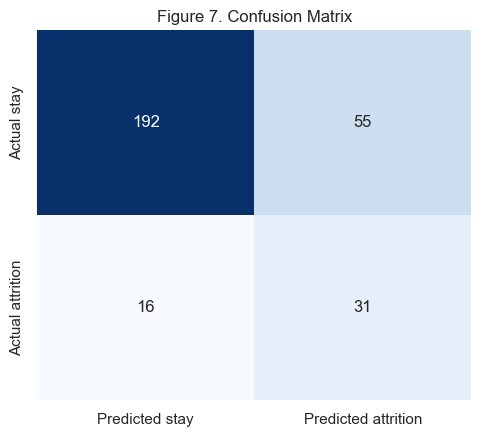

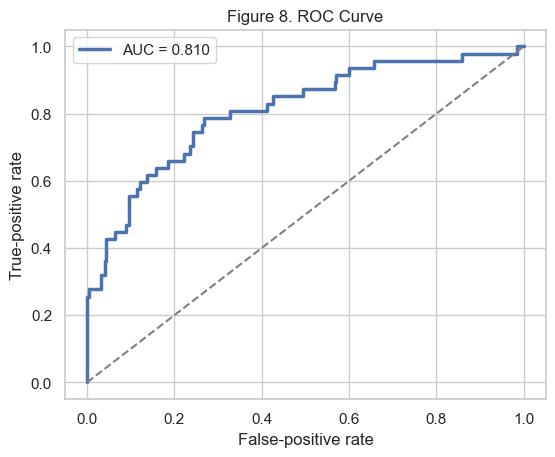

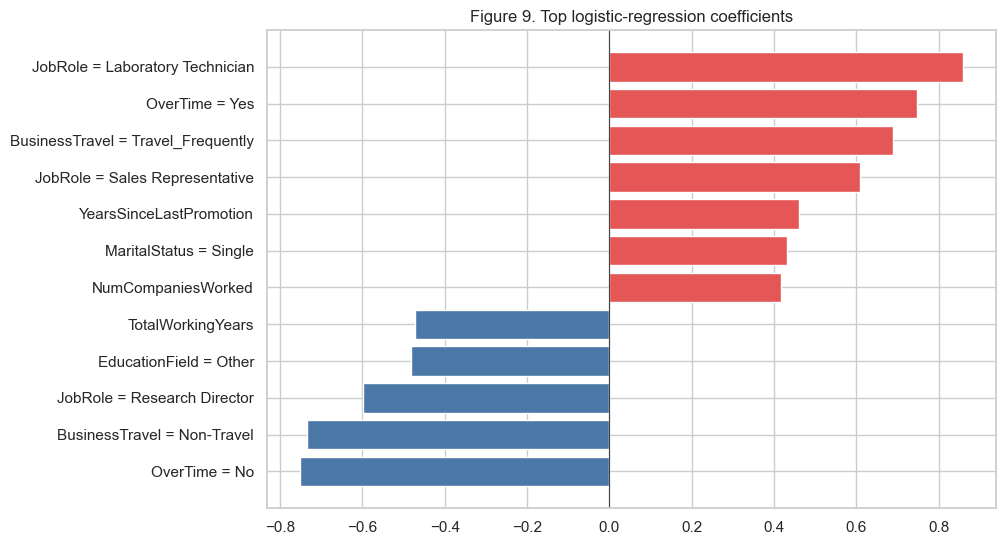


Selected model test metrics:
Accuracy: 0.7585034013605442
Precision: 0.36046511627906974
Recall: 0.6595744680851063
F1: 0.46616541353383456
ROC-AUC: 0.8104057197002327


In [28]:
rows = []
for name, pipe in fitted.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': name,
        'Train accuracy': pipe.score(X_train, y_train),
        'Test accuracy': accuracy_score(y_test, pred),
        'Precision (attrition)': precision_score(y_test, pred, zero_division=0),
        'Recall (attrition)': recall_score(y_test, pred, zero_division=0),
        'F1 (attrition)': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })
comparison = pd.DataFrame(rows).round(3)
display(comparison)

final_model = fitted['Balanced logistic regression']
test_pred = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)[:, 1]
print('\nClassification report (positive class = Attrition):')
print(classification_report(y_test, test_pred, target_names=['Stay', 'Attrition']))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5.6, 4.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted stay', 'Predicted attrition'],
            yticklabels=['Actual stay', 'Actual attrition'])
plt.title('Figure 7. Confusion Matrix')
plt.show()
save_figure('figure_7_confusion_matrix.png')


fpr, tpr, _ = roc_curve(y_test, test_proba)
plt.figure(figsize=(6.2, 4.8))
plt.plot(fpr, tpr, linewidth=2.5, label=f'AUC = {roc_auc_score(y_test, test_proba):.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False-positive rate'); plt.ylabel('True-positive rate')
plt.title('Figure 8. ROC Curve'); plt.legend()
plt.show() 
save_figure('figure_8_roc_curve.png')
     
names = final_model.named_steps['preprocessor'].get_feature_names_out()
coefs = final_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'Feature': names, 'Coefficient': coefs})
coef_df['Abs'] = coef_df['Coefficient'].abs()
top = coef_df.nlargest(12, 'Abs').sort_values('Coefficient')
top['Label'] = top['Feature'].str.replace('numeric__', '').str.replace('categorical__', '').str.replace('_', ' = ', n=1)
plt.figure(figsize=(9.4, 6.2))
plt.barh(top['Label'], top['Coefficient'], color=np.where(top['Coefficient'] >= 0, '#E45756', '#4C78A8'))
plt.axvline(0, color='#444444', linewidth=0.8)
plt.title('Figure 9. Top logistic-regression coefficients')
plt.show()
save_figure('figure_9_top_coefficients.png')
print('\nSelected model test metrics:')
print('Accuracy:', accuracy_score(y_test, test_pred))
print('Precision:', precision_score(y_test, test_pred))
print('Recall:', recall_score(y_test, test_pred))
print('F1:', f1_score(y_test, test_pred))
print('ROC-AUC:', roc_auc_score(y_test, test_proba))
plt.show()

## 9. Notes on interpretation

Results describe **associations** in a cross-sectional dataset. They support HR prioritization and further investigation; they do not prove causation or replace fair, human-led retention decisions.